# 11_数据预处理方法-数据拆分

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿的主要内容是：数据预处理方法-数据拆分\~

**什么是数据拆分？**

在机器学习或者数据分析中，我们通常会把数据分成**两部分或三部分**，这个过程就叫**数据拆分**。

**为什么要拆分？**

我们要让机器“学”和“考”，所以要把数据分成：

1. **训练集（Training Set）**：用来“教”模型怎么做（比如识别猫和狗）。
2. **测试集（Test Set）**：用来“考”模型学得怎么样（是不是真的能识别出没见过的猫和狗）。

有时候还会加一部分：

1. **验证集（Validation Set）**：用来“调试”模型，看看是不是哪里学偏了，需要调整。

**举个例子：**

假设你有一份包含1000张猫和狗的照片的数据集。

你可以这样拆分：

- 800张（80%）：用来训练模型（训练集）
- 100张（10%）：用来调整模型参数（验证集）
- 100张（10%）：用来最终测试模型表现（测试集）

**常见拆分比例：**

- **训练集：测试集 = 8:2**（最常见）
- 或者 **训练：验证：测试 = 6:2:2**

具体比例可以根据数据大小和需求来调整。

说白了，**数据拆分就是“教”+“调”+“考”模型的三步走，用不同的数据去做不同的事，避免“死记硬背”，提高模型的真实水平。**

## 原理详解

### 数学表达

设有一个**总体数据集**：


$$
\mathcal{D} = \{(x_1, y_1), (x_2, y_2), ..., (x_N, y_N)\}
$$


其中：

$x_i \in \mathbb{R}^d$：输入特征（如图像、数值、文本特征）

$y_i \in \mathbb{R}$ 或离散值：目标输出（标签）

$N$：样本总数

目标是用这个数据集来学习一个映射函数：


$$
f_\theta: \mathbb{R}^d \to \mathbb{R}
$$


使得预测值 $\hat{y}_i = f_\theta(x_i)$ 接近真实值 $y_i$。

---

### 泛化误差与经验误差

我们希望模型在**未知数据**上表现好，这就涉及两个核心误差：

- **经验误差（Empirical Risk）**：在训练数据上的平均误差  
$\hat{R}(\theta) = \frac{1}{n} \sum_{i=1}^{n} L(f_\theta(x_i), y_i)$
- **泛化误差（Generalization Error）**：在真实分布 $\mathcal{P}(x, y)$ 上的期望损失


$$
R(\theta) = \mathbb{E}_{(x, y) \sim \mathcal{P}}[L(f_\theta(x), y)]
$$


我们无法直接获得 $R(\theta)$，但可以用**测试集误差**近似。

---

### 数据拆分的数学动机

我们把数据拆分为：

- **训练集** $\mathcal{D}_{train}$：用于最小化经验误差
- **验证集** $\mathcal{D}_{val}$：用于模型调参（如选择正则项或模型结构）
- **测试集** $\mathcal{D}_{test}$：估计泛化能力，近似真实分布

满足：$\mathcal{D}_{train} \cup \mathcal{D}_{val} \cup \mathcal{D}_{test} = \mathcal{D}, \quad \mathcal{D}_{i} \cap \mathcal{D}_{j} = \emptyset, \quad i \neq j$

---

## 数据拆分的算法流程

我们以三种典型拆分方法进行详细推理：

### 1. Hold-Out 拆分法（固定比例划分）

1. **设定比例**：设定训练、验证、测试的比例为 $p_{train}, p_{val}, p_{test}$，满足：


$$
p_{train} + p_{val} + p_{test} = 1
$$


1. **样本均匀随机划分**：

   - 从总体数据 $\mathcal{D}$ 中**无放回抽样**选取 $N \cdot p_{train}$ 个样本作为训练集，
   - 选 $N \cdot p_{val}$ 个作为验证集，
   - 剩余为测试集。
2. **数学建模为抽样问题**：  
若样本服从独立同分布 $(x_i, y_i) \sim \mathcal{P}(x, y)$，  
则划分后各子集 $\mathcal{D}_{train}, \mathcal{D}_{val}, \mathcal{D}_{test}$ 同样近似于 $\mathcal{P}$。

由于我们关心泛化性能，我们需要让训练集与测试集尽可能**独立**，以近似真实情况。Hold-Out 法的理论基础是：

**独立同分布抽样 + 充足样本数量** ⇒ 可估计真实误差。

---

### 2. K-Fold 交叉验证（Cross-Validation）

1. 将数据集 $\mathcal{D}$ 等分成 $K$ 份：


$$
\mathcal{D} = \bigcup_{k=1}^K \mathcal{D}^{(k)}, \quad \mathcal{D}^{(i)} \cap \mathcal{D}^{(j)} = \emptyset
$$


1. 对每一轮 $i = 1, 2, ..., K$：

   - 用 $\mathcal{D}^{(i)}$ 作为验证集
   - 其余 $\mathcal{D} \setminus \mathcal{D}^{(i)}$ 为训练集
   - 训练模型并计算验证误差 $\hat{R}^{(i)}(\theta)$
2. 得到平均验证误差：


$$
\hat{R}_{cv}(\theta) = \frac{1}{K} \sum_{i=1}^{K} \hat{R}^{(i)}(\theta)
$$


1. K-Fold 的核心数学思想是：用不同的数据子集重复估计误差，减少「划分偶然性」带来的偏差。

它在有限样本情况下能更稳定地估计模型泛化能力。

---

### 3. 留一法（Leave-One-Out）

是 K-Fold 的特例，令 $K = N$：

- 每次只留下一个样本作为验证，其余 $N - 1$ 个训练
- 重复 N 次

得到：


$$
\hat{R}_{LOO}(\theta) = \frac{1}{N} \sum_{i=1}^N L(f_{\theta_{-i}}(x_i), y_i)
$$


其中 $\theta_{-i}$ 表示在第 $i$ 个样本以外的所有样本训练出来的模型。

**数学特性：**

- 是无偏估计（理论上非常准确）
- 计算开销大（每次都要训练一次模型）

## 完整案例

依据上面的理论，这里给出对应的案例，大家可以作为参考：

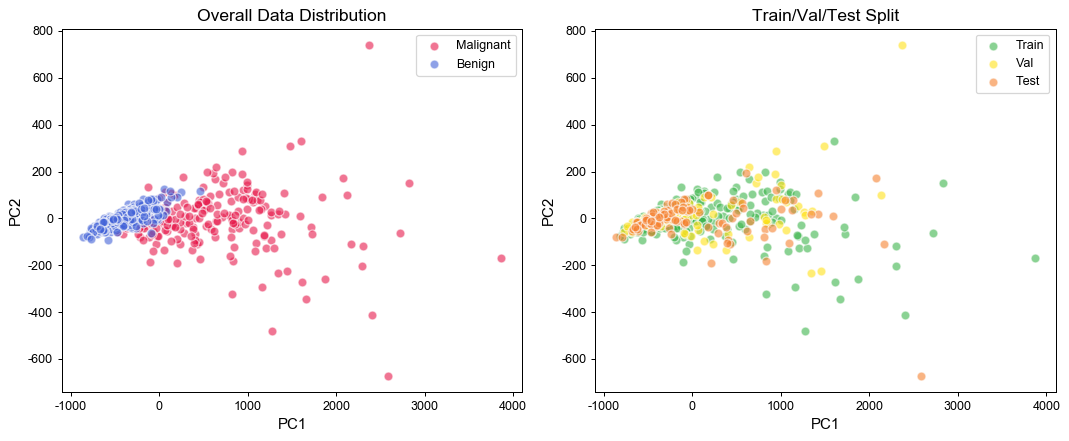

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score

# 1. 数据加载与初步处理
data = load_breast_cancer()
X = data.data
y = data.target
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

# 2. 随机拆分: Train/Val/Test = 60/20/20
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25*0.8=0.2

# 3. PCA降维至2D以便可视化
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
X_train_pca = pca.transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# 4. 可视化: 整体样本分布 & 拆分后的数据集分布
plt.figure(figsize=(12, 5))

# 整体样本分布
plt.subplot(1, 2, 1)
for cls, color, label in zip([0, 1], ['#e6194b', '#4363d8'], ['Malignant', 'Benign']):
    mask = (y == cls)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label, alpha=0.6, edgecolors='w', s=50)
plt.title('Overall Data Distribution', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend()

# 拆分后分布
plt.subplot(1, 2, 2)
for Xp, label, color in zip([X_train_pca, X_val_pca, X_test_pca], 
                             ['Train', 'Val', 'Test'], 
                             ['#3cb44b', '#ffe119', '#f58231']):
    plt.scatter(Xp[:, 0], Xp[:, 1], c=color, label=label, alpha=0.6, edgecolors='w', s=50)
plt.title('Train/Val/Test Split', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Random Split Accuracy (Val): 0.9649
Random Split Accuracy (Test): 0.9649
Train Distribution: {np.int64(0): np.float64(0.367), np.int64(1): np.float64(0.633)}
Val Distribution: {np.int64(0): np.float64(0.386), np.int64(1): np.float64(0.614)}
Test Distribution: {np.int64(0): np.float64(0.377), np.int64(1): np.float64(0.623)}


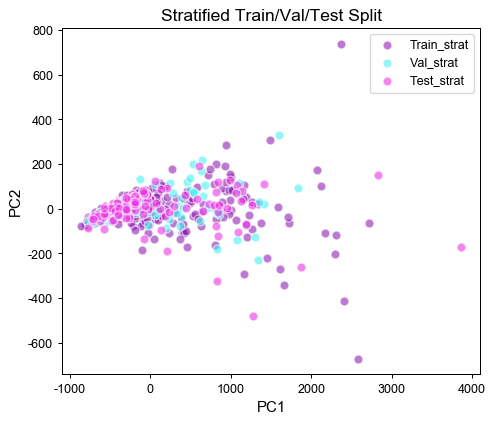

Stratified Split Accuracy (Val): 0.9474
Stratified Split Accuracy (Test): 0.9561
Train_strat Distribution: {np.int64(0): np.float64(0.372), np.int64(1): np.float64(0.628)}
Val_strat Distribution: {np.int64(0): np.float64(0.377), np.int64(1): np.float64(0.623)}
Test_strat Distribution: {np.int64(0): np.float64(0.368), np.int64(1): np.float64(0.632)}


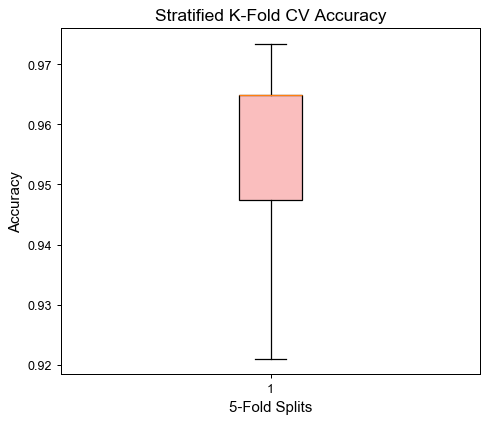

In [3]:
# 5. 基线模型评估: Logistic Regression
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)
y_pred_val = model.predict(X_val)
y_pred_test = model.predict(X_test)
acc_val_rand = accuracy_score(y_val, y_pred_val)
acc_test_rand = accuracy_score(y_test, y_pred_test)

print("Random Split Accuracy (Val): {:.4f}".format(acc_val_rand))
print("Random Split Accuracy (Test): {:.4f}".format(acc_test_rand))

# 6. 类别分布对比 (随机拆分)
def print_distribution(y, name):
    unique, counts = np.unique(y, return_counts=True)
    ratios = counts / counts.sum()
    print(f"{name} Distribution: {dict(zip(unique, np.round(ratios, 3)))}")

print_distribution(y_train, "Train")
print_distribution(y_val, "Val")
print_distribution(y_test, "Test")

# 7. 优化: 分层拆分 (Stratified Split)
X_temp_s, X_test_s, y_temp_s, y_test_s = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(X_temp_s, y_temp_s, test_size=0.25, stratify=y_temp_s, random_state=42)

# PCA降维
X_train_s_pca = pca.transform(X_train_s)
X_val_s_pca = pca.transform(X_val_s)
X_test_s_pca = pca.transform(X_test_s)

# 可视化分层拆分
plt.figure(figsize=(6, 5))
for Xp, label, color in zip([X_train_s_pca, X_val_s_pca, X_test_s_pca], 
                             ['Train_strat', 'Val_strat', 'Test_strat'], 
                             ['#911eb4', '#46f0f0', '#f032e6']):
    plt.scatter(Xp[:, 0], Xp[:, 1], c=color, label=label, alpha=0.6, edgecolors='w', s=50)
plt.title('Stratified Train/Val/Test Split', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend()
plt.show()

# 模型评估 (分层拆分)
model_s = LogisticRegression(max_iter=10000, random_state=42)
model_s.fit(X_train_s, y_train_s)
acc_val_strat = accuracy_score(y_val_s, model_s.predict(X_val_s))
acc_test_strat = accuracy_score(y_test_s, model_s.predict(X_test_s))

print("Stratified Split Accuracy (Val): {:.4f}".format(acc_val_strat))
print("Stratified Split Accuracy (Test): {:.4f}".format(acc_test_strat))

# 类别分布对比 (分层拆分)
print_distribution(y_train_s, "Train_strat")
print_distribution(y_val_s, "Val_strat")
print_distribution(y_test_s, "Test_strat")

# 8. 进一步优化: Stratified K-Fold 交叉验证
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = []

for train_idx, val_idx in skf.split(X, y):
    X_tr, X_vl = X[train_idx], X[val_idx]
    y_tr, y_vl = y[train_idx], y[val_idx]
    clf = LogisticRegression(max_iter=10000, random_state=42)
    clf.fit(X_tr, y_tr)
    acc_scores.append(accuracy_score(y_vl, clf.predict(X_vl)))

# 可视化交叉验证结果
plt.figure(figsize=(6, 5))
plt.boxplot(acc_scores, patch_artist=True, boxprops=dict(facecolor='#fabebe', edgecolor='#000000'))
plt.title('Stratified K-Fold CV Accuracy', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('5-Fold Splits', fontsize=12)
plt.show()

In [4]:
print("CV Accuracy Mean: {:.4f}, Std: {:.4f}".format(np.mean(acc_scores), np.std(acc_scores)))

CV Accuracy Mean: 0.9543, Std: 0.0187


### 1. 数据加载与初步处理

我们使用`sklearn.datasets`中的乳腺癌数据集，这是一份常见的二分类数据集（569条样本，30维特征）。

转换为DataFrame方便后续统计、可视化和分组操作。

### 2. 随机拆分 (Hold-Out Split)

最常见的“Hold-Out”方法，将数据按比例随机拆分为训练集、验证集和测试集。

其中，`random_state=42` 保证每次拆分的可重复性。验证集用于调参，测试集用于最后评估泛化能力。

### 3. PCA降维可视化

这里，咱们使用PCA降到2维。

`fit_transform`在全集上学习主成分，再用同样的映射投影到各子集，保持一致性。

### 4. 可视化整体数据与拆分结果

- **左图**：使用不同颜色，展示全集投影后样本分布。
- **右图**：使用三种颜色分别绘出三部分在二维空间的分布。

直观检查拆分后各子集是否均匀覆盖整个数据空间，避免训练集只集中在某一簇。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

### 5. 基线模型评估（随机拆分下的性能）

用最简单的逻辑回归模型评估，在随机拆分下的验证集和测试集准确率。

**结果**：

- 验证集：0.9649
- 测试集：0.9649

验证和测试准确率非常接近，说明模型没有明显过拟合。但单次拆分结果可能有偶然性。

### 6. 拆分后类别分布检查

打印训练、验证、测试集中每个类别（0=Malignant, 1=Benign）的比例。

**随机拆分结果**：

- Train: {0:0.367, 1:0.633}
- Val: {0:0.386, 1:0.614}
- Test: {0:0.377, 1:0.623}

比例相近，但在数据量更小或更极端不平衡时，随机拆分可能造成较大偏差。

### 7. 优化拆分：分层抽样 (Stratified Split)

`stratify=y` 保证每个子集中类别比例与原数据一致。

**分层拆分结果**：

- Train_strat: {0:0.372, 1:0.628}
- Val_strat: {0:0.377, 1:0.623}
- Test_strat: {0:0.368, 1:0.632}

更精确地维持了类别比例，特别适合类别不平衡场景。

#### 可视化对比

使用不同配色（紫、青、粉）展示分层拆分后的二维分布。保证在每个区域、每个比例都一致。

![原文参考图，当前结果见代码输出](attachments/img_009.png)

#### 分层拆分下的模型评估

In [5]:
acc_val_strat = accuracy_score(y_val_s, model_s.predict(X_val_s))
acc_test_strat = accuracy_score(y_test_s, model_s.predict(X_test_s))

- 验证集：0.9474
- 测试集：0.9561

与随机拆分相比，略微波动，但可在多次实验中更稳定。

### 8. 进一步优化：Stratified K-Fold 交叉验证

将数据分为5折，每次使用4折训练、1折验证，且保证每折的类别比例一致。

**结果展示**：

- 用箱线图 (`plt.boxplot`) 展示5次拆分的验证准确率分布。
- Mean: 0.9543, Std: 0.0187

![原文参考图，当前结果见代码输出](attachments/img_010.png)

**分析**：

**平均准确率** 更能反映方法性能；

**标准差** 表征不确定性（越小越稳定）。

**算法优化思路总结**：

- 对于**类别平衡**：使用 `stratify` 参数。
- 对于**评估稳定性**：使用交叉验证（`StratifiedKFold`）。
- 对于**可视化检查**：先 PCA 降维，再绘制分布图，观察各子集覆盖情况。

## 模型分析

### 优缺点总结

**优点：**

1. **结构清晰，流程标准**：数据拆分（训练/验证/测试）是机器学习建模的核心步骤，能够有效防止“信息泄露”，保障模型泛化能力。
2. **训练与评估职责分离**：训练集专用于建模，验证集用于调参，测试集专门用于最终性能评估，流程干净，避免数据重用导致过拟合风险。
3. **分层拆分提升公平性**：特别在类别不平衡的数据集中，`stratify=y` 确保每个子集保持相同比例，避免某一类数据因拆分波动而被低估或忽视。
4. **易于可视化分析**：搭配 PCA 降维后，训练/验证/测试集的空间分布直观可见，便于发现异常拆分或数据泄露问题。
5. **可拓展性强**：拆分策略可以嵌入网格搜索、交叉验证流程，与其他模型管线高度兼容。

**缺点：**

1. **固定拆分带来的随机性问题**：一次性拆分可能因偶然性导致模型评估不准确，特别是在数据量小或类别极不平衡的情形下。
2. **验证集过小导致性能估计偏差**：如果验证集样本太少，调参时容易受偶然误差影响，调优方向不稳。
3. **训练数据减少，影响模型学习**：每拆分一次数据，实际能用于训练的样本就减少，模型训练可能不充分。
4. **对分布变化敏感**：若数据呈现时间序列或区域依赖特性，随机拆分可能破坏其结构，导致“未来泄露”或空间误解。

### 与相似算法对比

| 方法 | 是否保持类别比例 | 是否使用全部数据训练 | 稳定性（低=波动大） | 适用场景 |
|-|-|-|-|-|
| **随机拆分（Random Split）** | 否 | 否 | 中 | 数据量大，模型训练快速时优选 |
| **分层拆分（Stratified Split）** | 是 | 否 | 中 | 类别不平衡数据；中等样本量；关注公平性 |
| **K折交叉验证（K-Fold CV）** | 否 | 是 | 中高 | 数据量少；需稳定评估；但忽略类别比例 |
| **Stratified K-Fold CV** | 是 | 是 | 高 | 小样本 + 类别不均衡；精细调参，准确评估 |
| **留一法（LOOCV）** | 是 | 是 | 非常高 | 极小数据集；极致稳定评估；计算成本高 |
| **时间序列拆分** | 否 | 是 | 高 | 有时序关系数据（如金融、传感器、天气等） |

### 何时优选使用本案例的拆分策略

**推荐使用场景：**

- 中等数据量（几千\~几万）；
- 二分类或多分类任务，类别比例差异明显；
- 模型调参周期短，希望快速反馈验证性能；
- 需要有验证集与测试集双重评估标准；
- 不考虑时间依赖性或空间相关性；
- 使用可视化检验分布时，希望保持清晰的标签划分。

### 何时考虑其他数据拆分策略

**考虑替代方案的情况：**

1. **数据量极少（<500）**：使用 `Stratified K-Fold CV` 或 `LOOCV`，可重复使用数据提升训练能力和评估可靠性。
2. **数据有时序结构（金融预测、传感器信号）**：使用 `TimeSeriesSplit`，避免未来信息“泄露”到训练中。
3. **希望更准确的泛化评估**：使用 `Stratified K-Fold CV`，计算平均性能和标准差，避免对单次划分的过度依赖。
4. **模型训练时间非常短，资源充足**：可以使用交叉验证或嵌套交叉验证（Nested CV）进行模型选择与评估。

### 实践总结

在绝大多数普通机器学习任务中，推荐使用**Stratified拆分（分层）**代替纯粹的随机拆分。它更公平、更稳定，并且在数据中体现的类别结构可以更好地保留下来，是工业界和研究中常用的标准策略之一。